# Noise and signal correlation in simultaneously recorded selective pairs

Every pair here is **two FDR-selective units recorded simultaneously**. Two
things are measured on those same pairs.

| | signal correlation | noise correlation |
|---|---|---|
| computed on | condition-averaged rate timelines | per-fixation 1 ms spike trains |
| asks | do their **mean responses** share a shape | do they fire together on the **same** fixation |
| null | unit of the same region, different session | circular shift within fixation |
| units | Pearson coefficient, −1 to 1 | spike pairs per fixation, unnormalised |

Averaging over fixations removes trial-by-trial covariation entirely. That is
the only difference between the two paths in the schematic, and it is why a pair
can have either without the other.

Within-region pairs come first, then the three cross-region combinations the
recordings support — all of which involve BLA, since ACCg and OFC were never
recorded together and dmPFC × OFC comes from a handful of sessions.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview


/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/plotting/fixation_pair_correlation_overview.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.13, 1, 0.87))


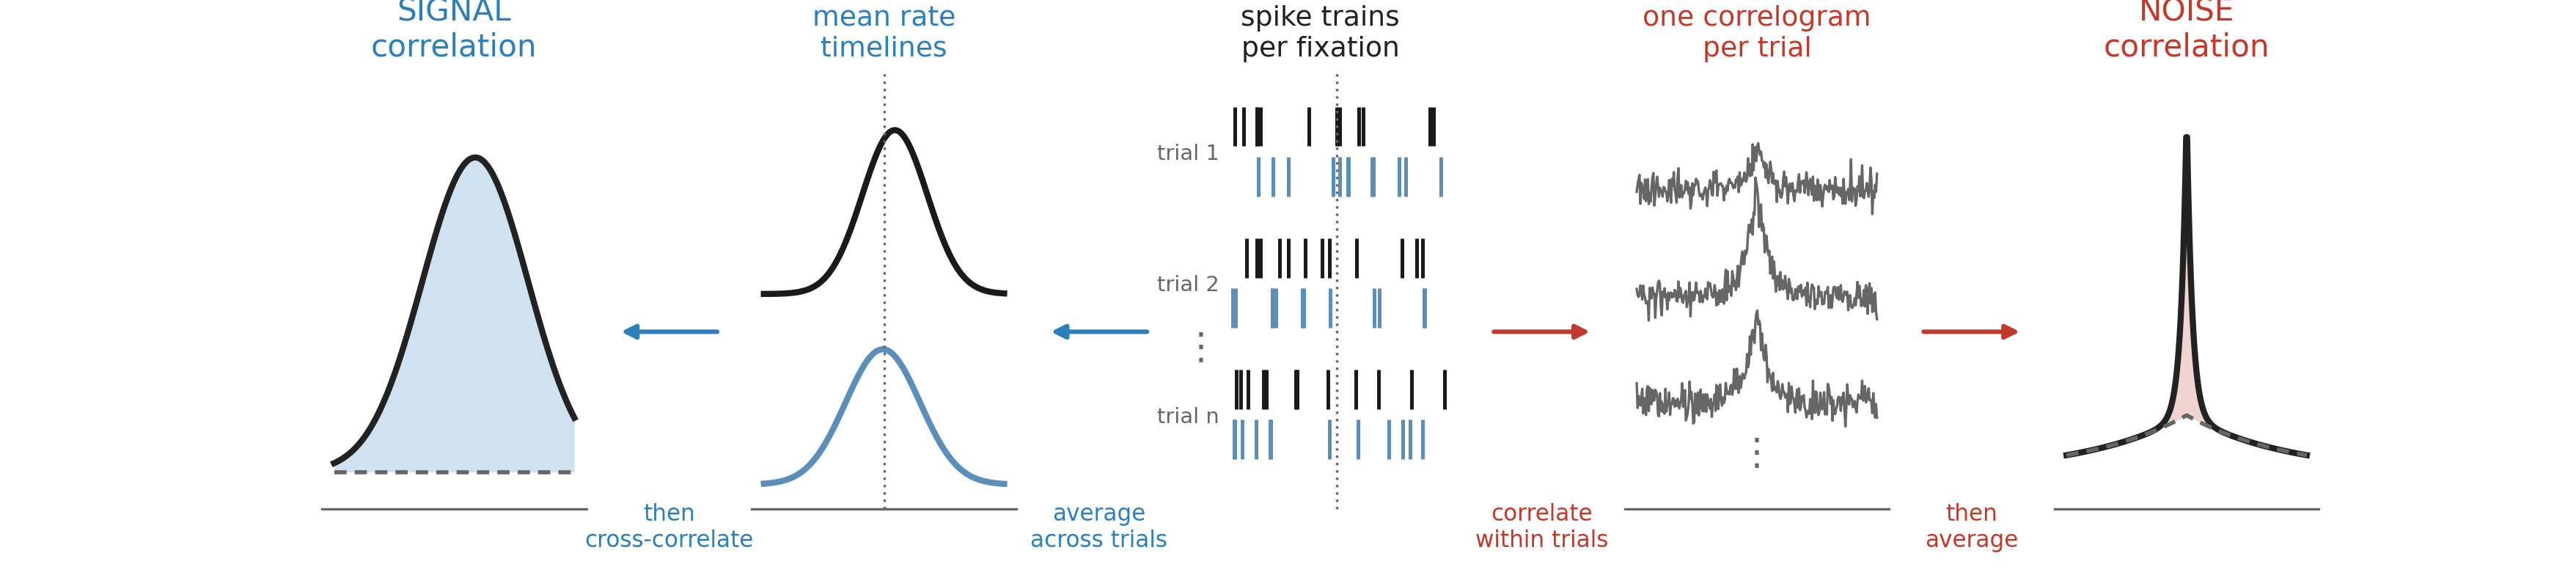

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

## What is in the analysis

In [3]:
# --- noise correlation: per-fixation spike trains, circular-shift null -------
noise = psc.load_pair_coordination(CFG_PATH)[0]
noise, dropped = psc.drop_zero_lag_artifact_dates(noise)
noise = noise.loc[noise["both_selective"]].copy()
noise["scope"] = np.where(noise["same_region"], "within_region", "cross_region")
noise_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"noise: {len(noise):,} pair-conditions, both units FDR-selective   "
      f"(artifact dates removed: {dropped})")

# --- signal correlation: condition-averaged timelines, cross-session null ----
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
print(f"signal: {len(signal):,} pairs from {len(units)} FDR-selective units")

joined = sc.join_with_noise_correlation(
    signal, signal_settings, signal_metric=sc.WINDOW_METRIC
)
correlations = sc.correlate_signal_with_noise(joined)

display(
    signal.groupby(["scope", "region_pair"], observed=True)
    .size().rename("signal_pairs").to_frame()
)

noise: 114,786 pair-conditions, both units FDR-selective   (artifact dates removed: ['09272018', '09292018'])


signal: 5,206 pairs from 574 FDR-selective units


signal_pairs
scope         region_pair              
cross_region  accg-bla              752
              accg-dmpfc             43
              bla-dmpfc             847
              bla-ofc               559
within_region accg                  356
              bla                  1786
              dmpfc                 320
              ofc                   543

# Within region

## 1. Signal correlation

The cross-session null is subtracted, so zero means "resembles a same-region
unit from another session no more than chance".

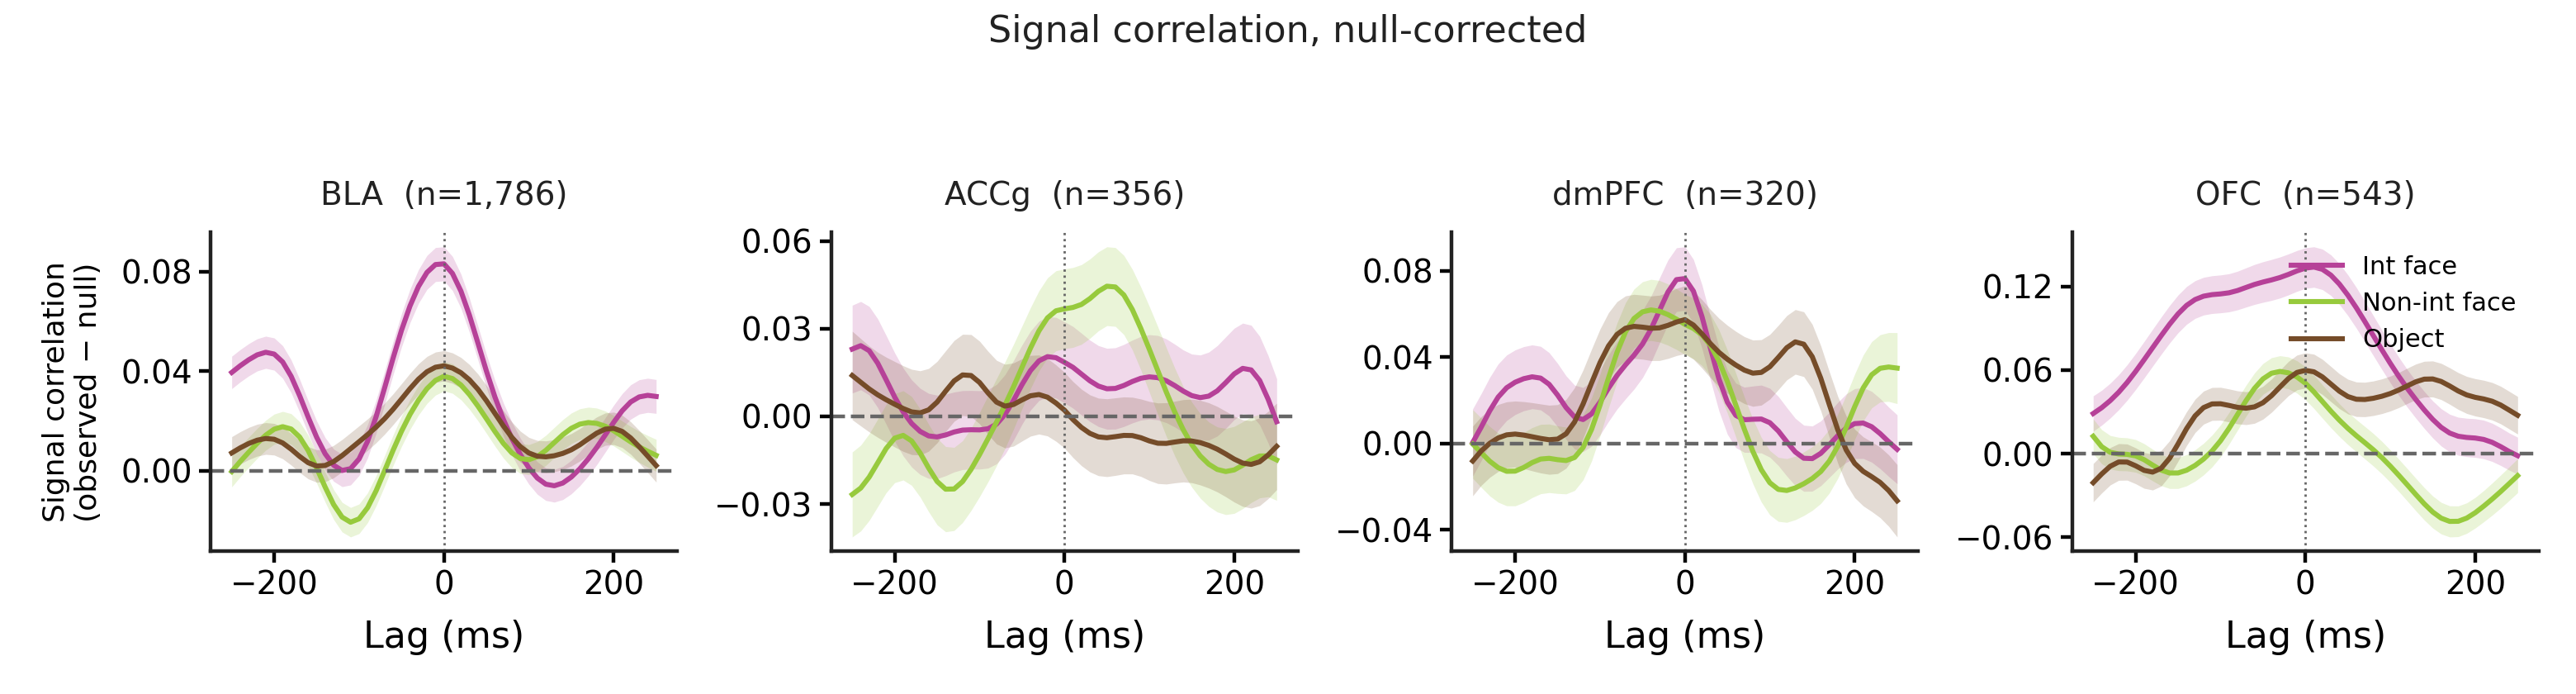

In [4]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="within_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig02_signal_excess",
)
display(Image(filename=str(paths["png"])))

## 2. Noise correlation

Rows are fixation conditions, columns are regions. The gap between the two
curves is the coordination — the observed curve alone is not, since an
unnormalised cross-correlation scales with the product of the two firing rates.

The three rows look alike, which is the result: fixation type does not modulate
noise correlation.

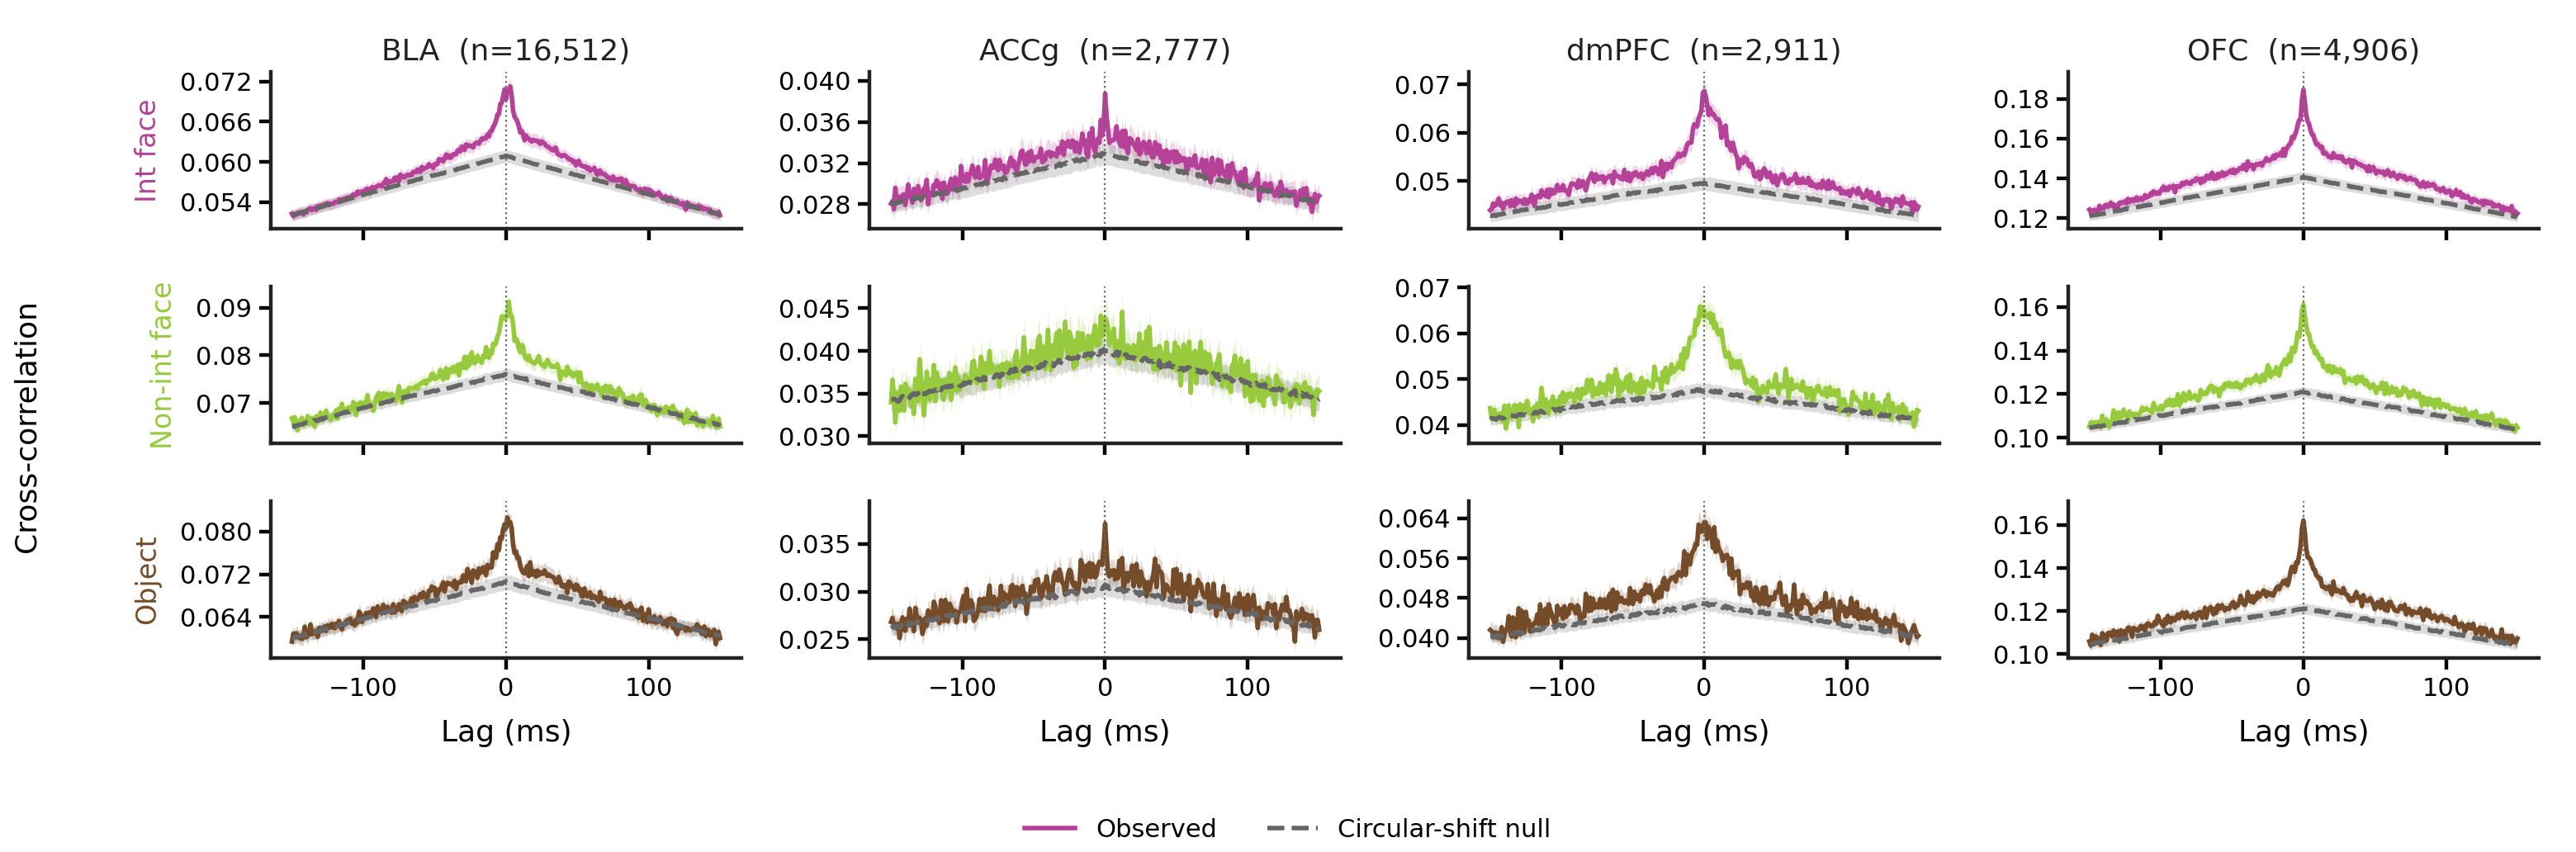

In [5]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs, scope="within_region")
display(Image(filename=str(paths["png"])))

## 3. Summary

**Left**: null-corrected signal correlation, summarised as the mean over ±100 ms
— not at zero lag, which is one bin of fifty, and not at the peak, whose
per-pair maximum falls at a different lag for every pair and so averages to a
much larger number than the maximum of the average. The windowed mean takes no
maximum anywhere, so these bars and the traces in section 1 are the same
quantity. Brackets appear only where a contrast survives FDR.

**Right**: the Spearman correlation between each pair's signal and noise
correlation. A positive value means pairs whose mean responses resemble each
other also tend to co-fire trial to trial — which is not guaranteed, since the
two come from different operations on the same trains.

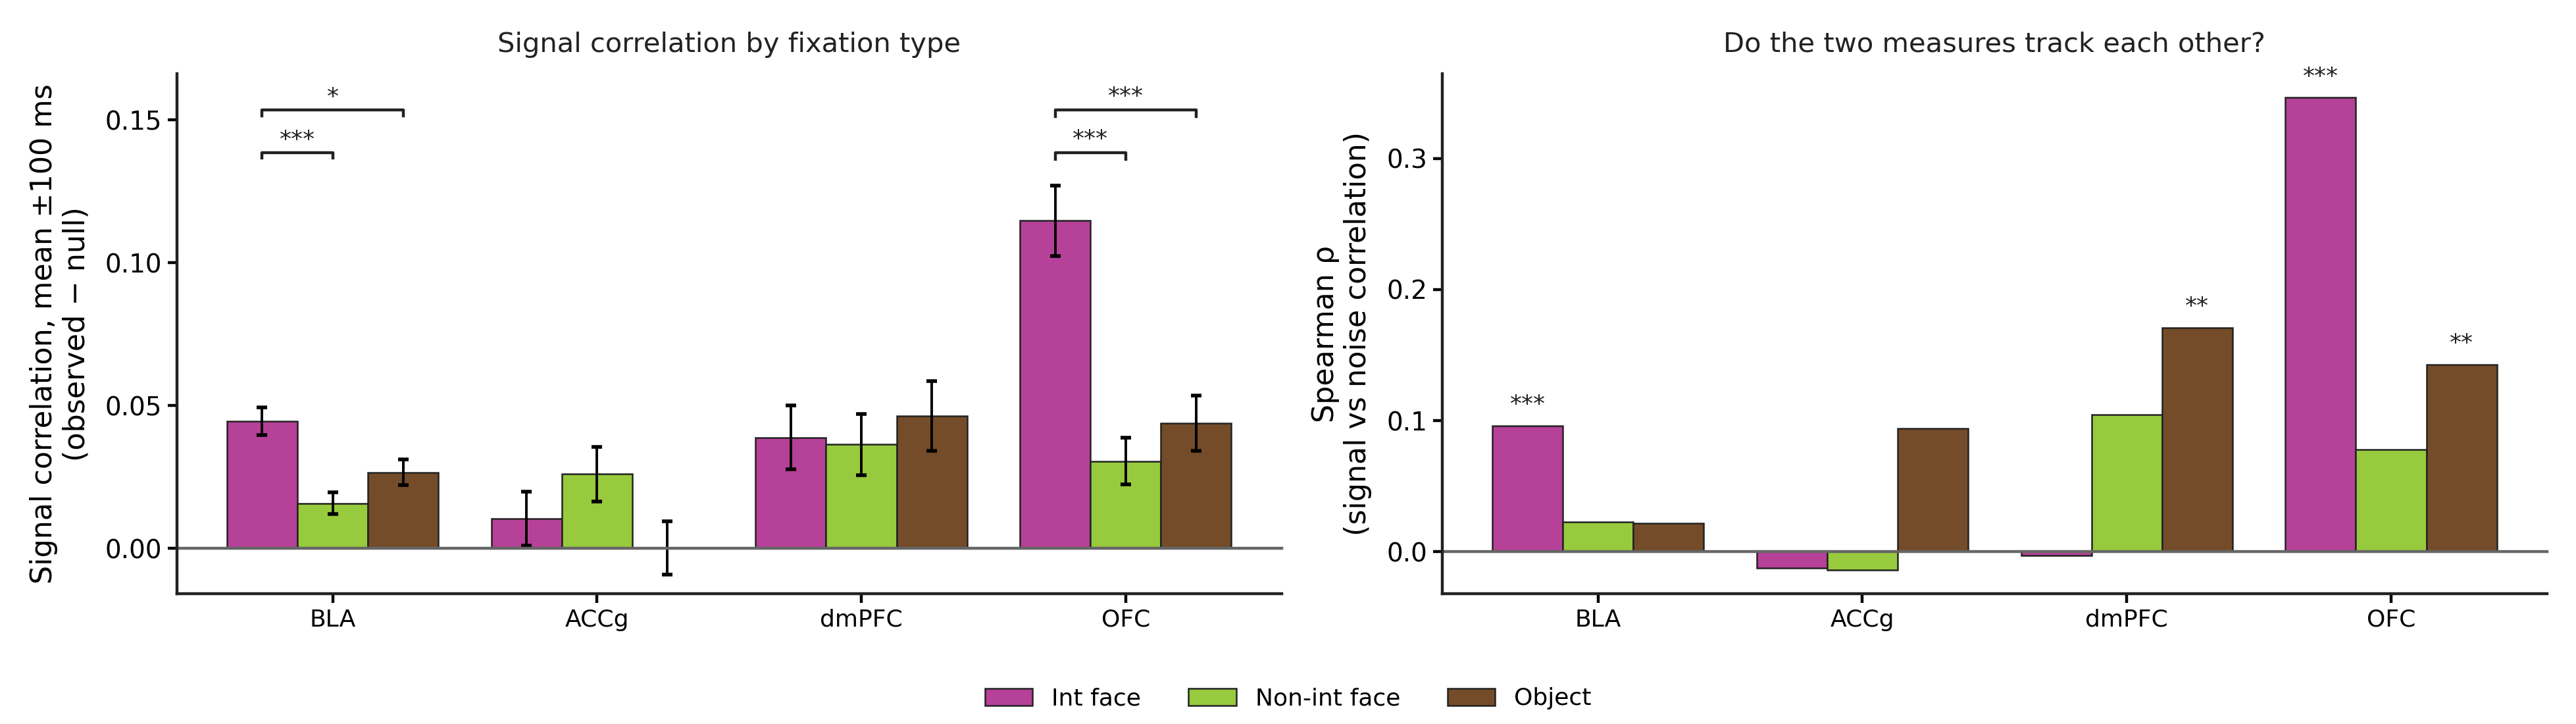

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0105,0.0260,0.0002
bla,0.0445,0.0158,0.0267
dmpfc,0.0389,0.0364,0.0464
ofc,0.1147,0.0306,0.0438


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,356,-0.0155,0.0000,0.3564,False
1,accg,face_interactive,object,356,0.0103,0.0506,0.5853,False
2,accg,face_non_interactive,object,356,0.0258,0.1124,0.0888,False
3,bla,face_interactive,face_non_interactive,1786,0.0287,0.0907,0.0000,True
4,bla,face_interactive,object,1786,0.0178,0.0504,0.0111,True
5,bla,face_non_interactive,object,1786,-0.0109,-0.0291,0.2308,False
6,dmpfc,face_interactive,face_non_interactive,320,0.0025,-0.0312,0.8619,False
7,dmpfc,face_interactive,object,320,-0.0076,0.0000,0.8055,False
8,dmpfc,face_non_interactive,object,320,-0.0101,0.0250,0.9092,False
9,ofc,face_interactive,face_non_interactive,543,0.0842,0.2523,0.0000,True


,region_pair,condition,n_pairs,spearman_rho,p_value
9,accg,face_interactive,354,-0.0128,0.8107
10,accg,face_non_interactive,325,-0.0143,0.7979
11,accg,object,351,0.0941,0.0782
12,bla,face_interactive,1714,0.0962,0.0001
13,bla,face_non_interactive,1656,0.0227,0.3557
14,bla,object,1617,0.0218,0.3800
15,dmpfc,face_interactive,320,-0.0029,0.9587
16,dmpfc,face_non_interactive,318,0.1043,0.0632
17,dmpfc,object,314,0.1709,0.0024
18,ofc,face_interactive,527,0.3467,0.0000


In [6]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="within_region"
)
rho = correlations.loc[correlations["scope"] == "within_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="within_region")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

# Across regions

Only BLA × ACCg, BLA × dmPFC and BLA × OFC are populated enough to report.

## 4. Signal correlation

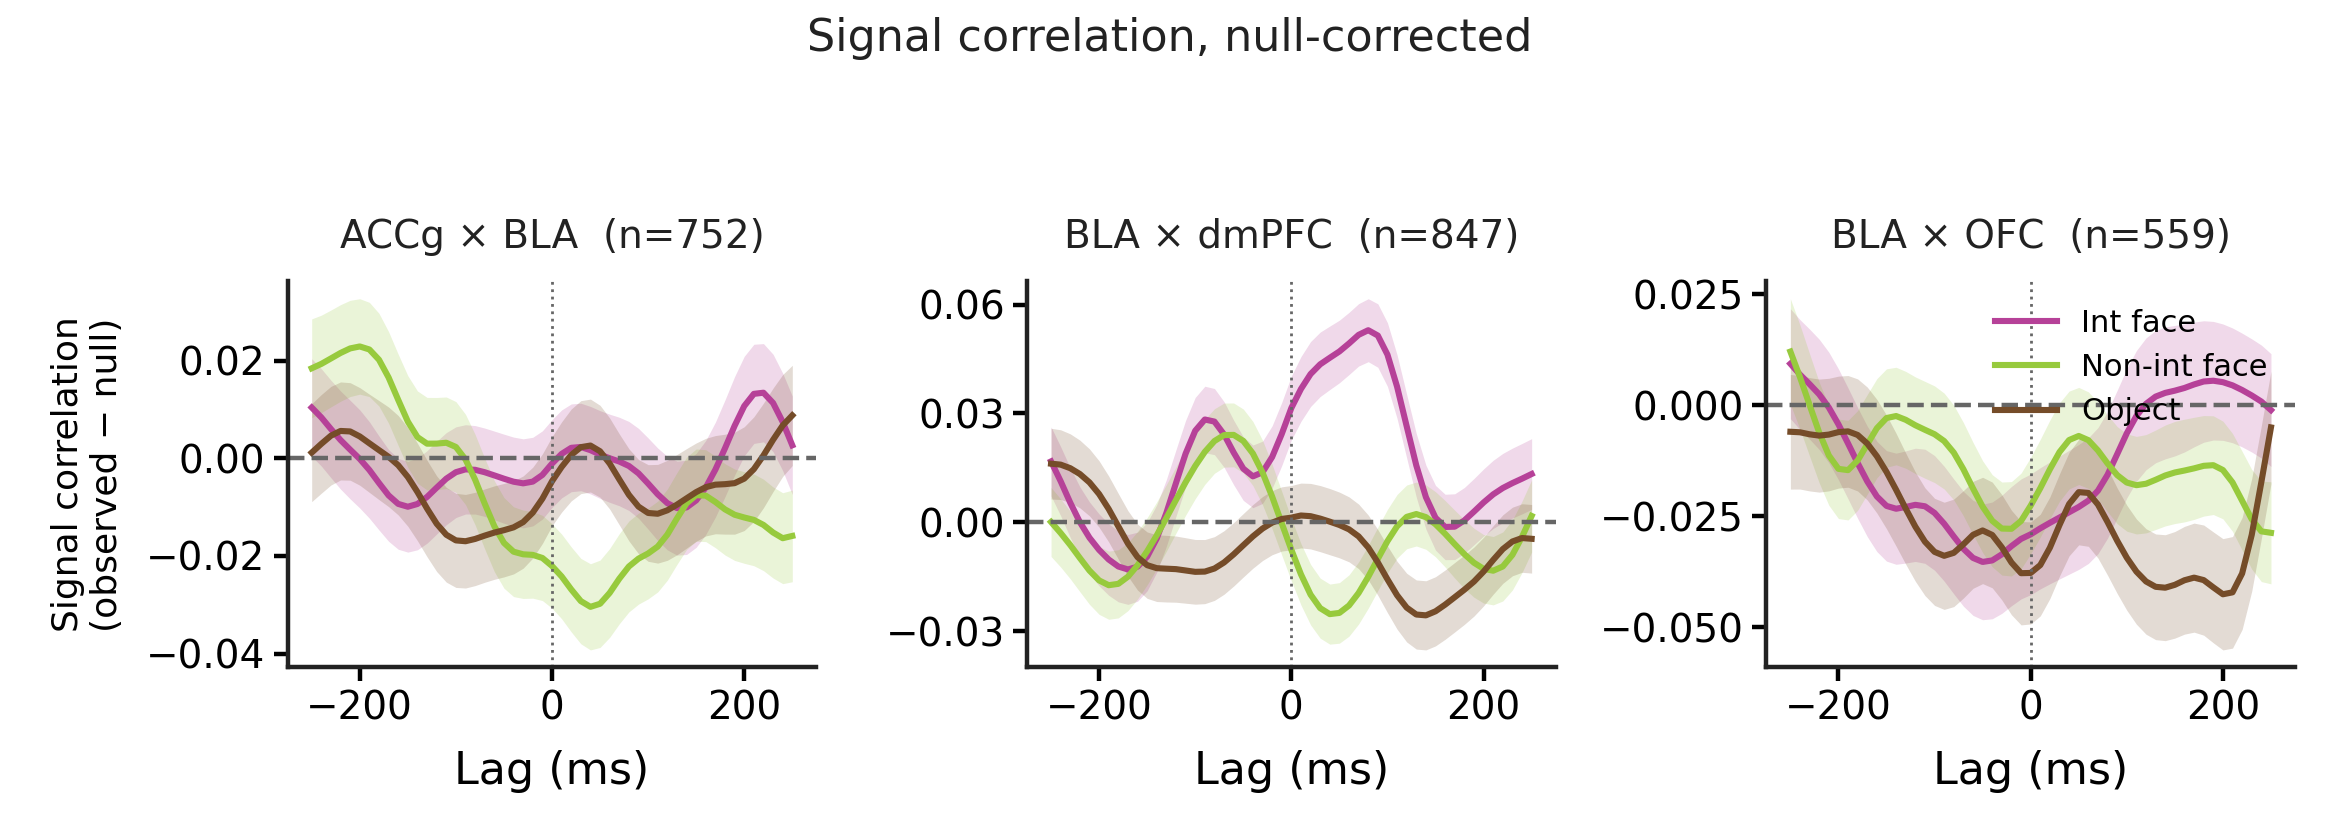

In [7]:
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, scope="cross_region", max_lag_ms=250.0,
    ylabel="Signal correlation\n(observed − null)",
    title="Signal correlation, null-corrected",
    stem="fig02_signal_excess",
)
display(Image(filename=str(paths["png"])))

## 5. Noise correlation

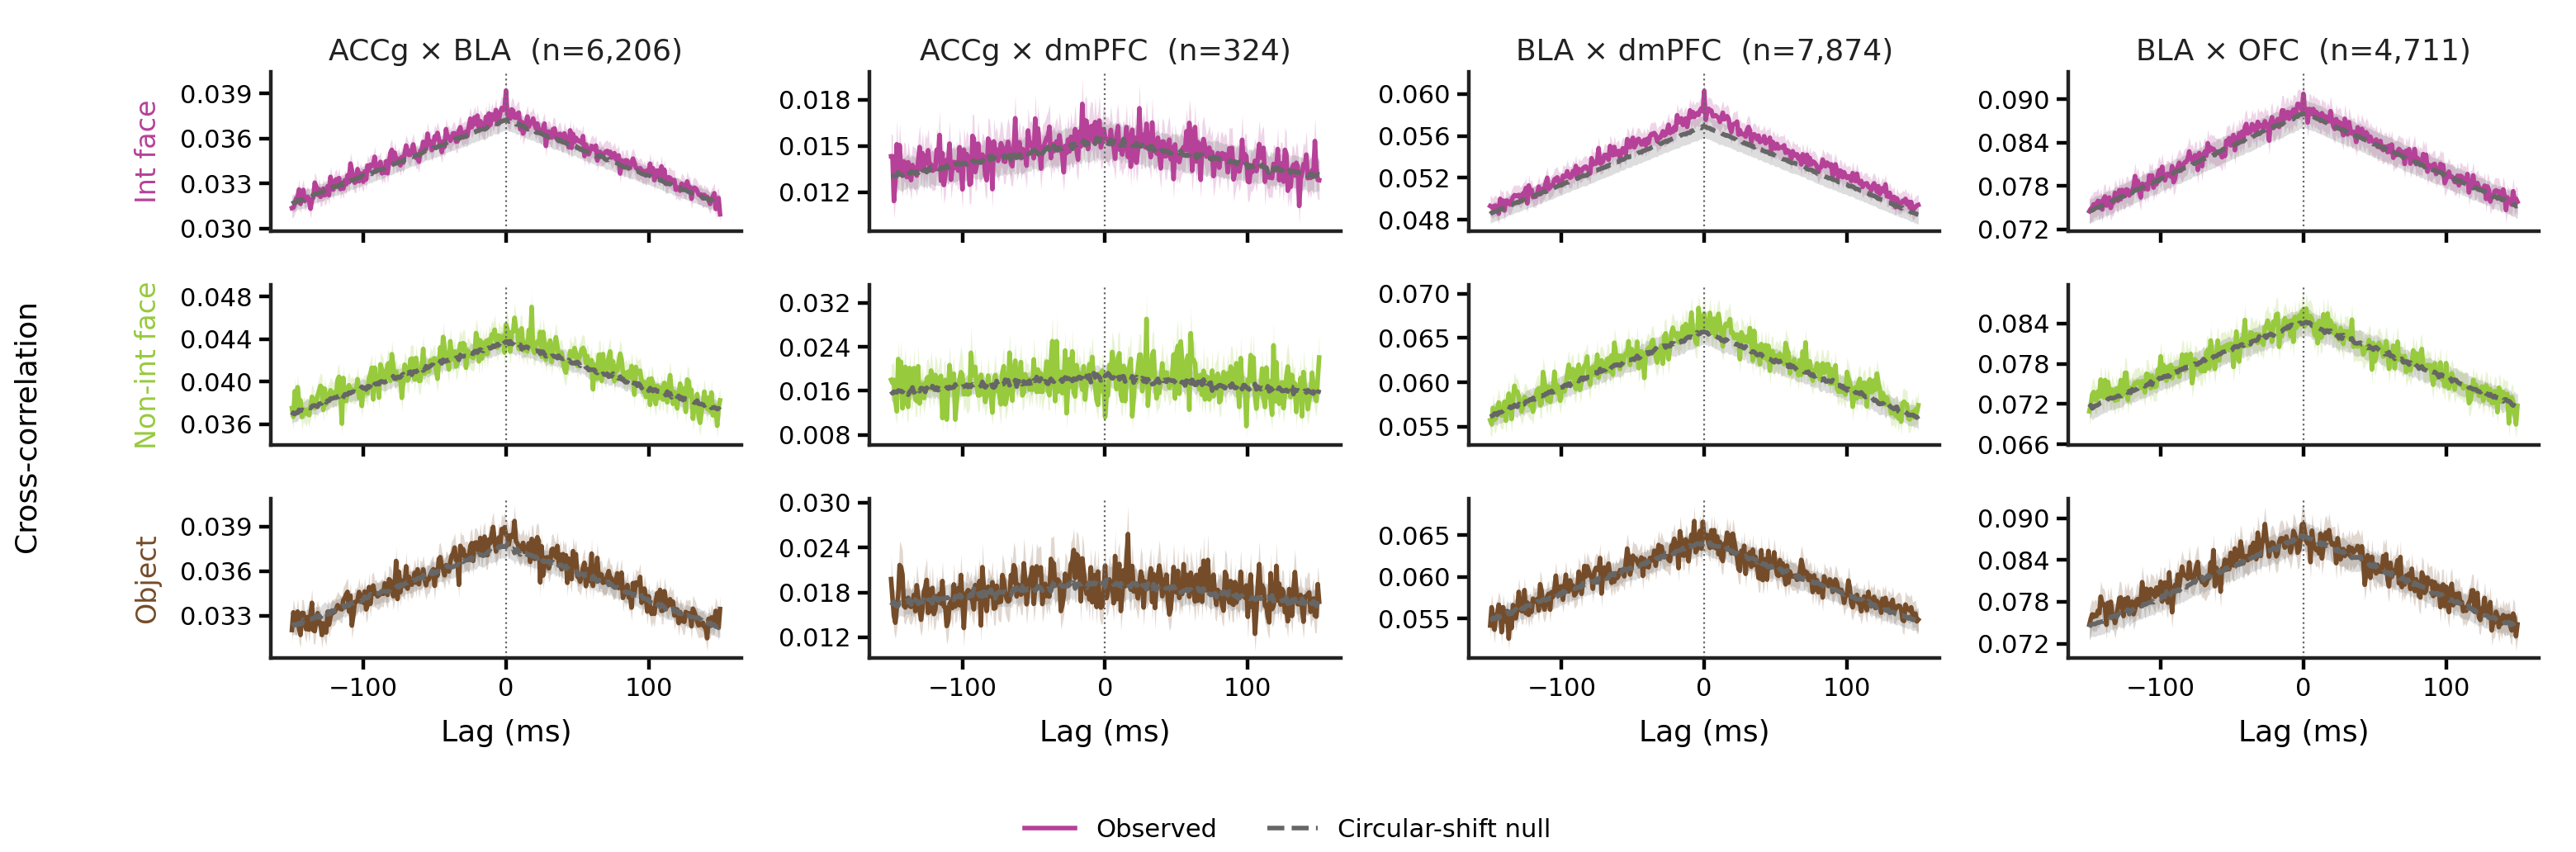

In [8]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs, scope="cross_region")
display(Image(filename=str(paths["png"])))

## 6. Summary

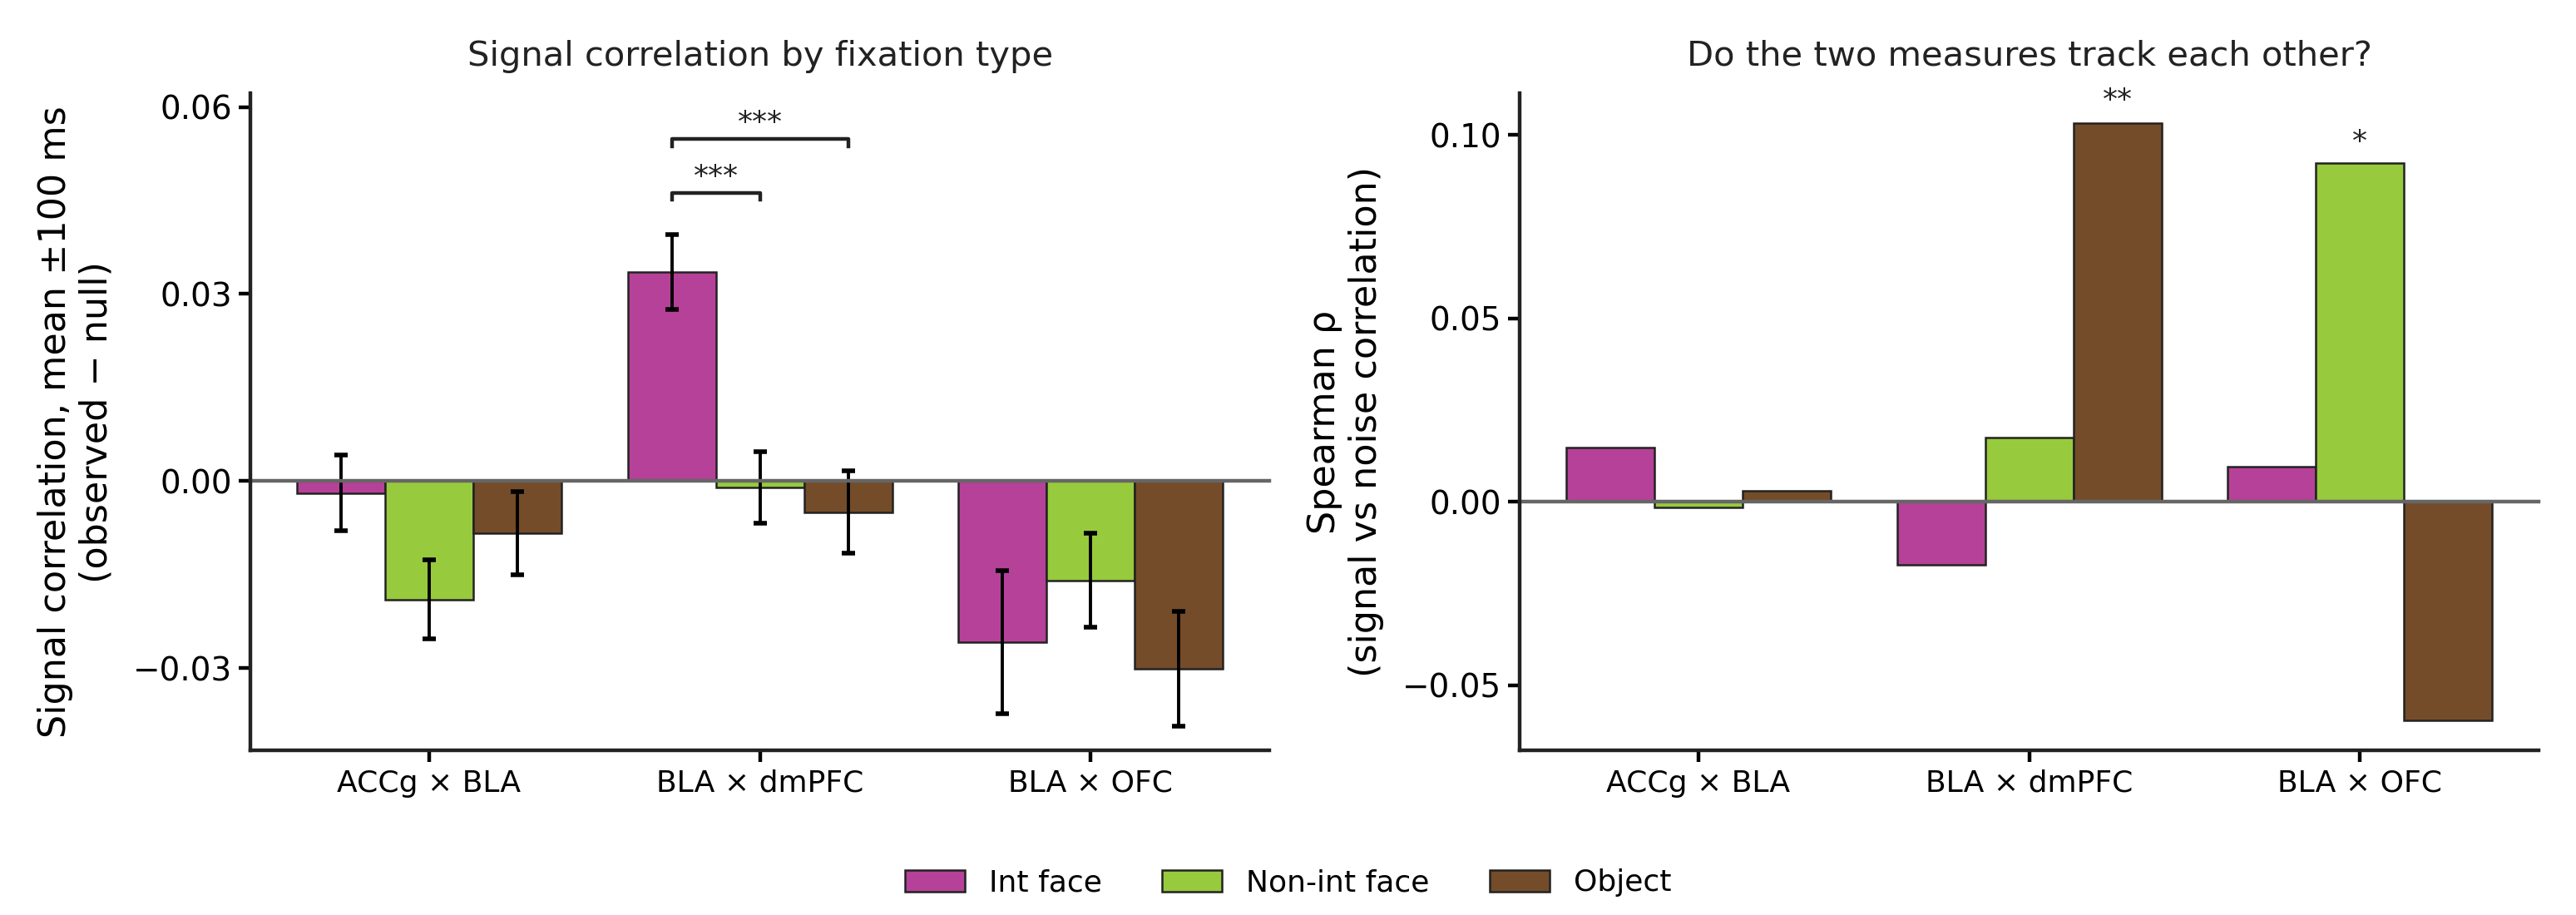

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg-bla,-0.0019,-0.0190,-0.0084
bla-dmpfc,0.0336,-0.0010,-0.0050
bla-ofc,-0.0258,-0.0159,-0.0301


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg-bla,face_interactive,face_non_interactive,752,0.0171,0.0612,0.1480,False
1,accg-bla,face_interactive,object,752,0.0065,0.0106,0.7089,False
2,accg-bla,face_non_interactive,object,752,-0.0106,-0.0186,0.7089,False
3,bla-dmpfc,face_interactive,face_non_interactive,847,0.0346,0.0744,0.0005,True
4,bla-dmpfc,face_interactive,object,847,0.0386,0.1192,0.0001,True
5,bla-dmpfc,face_non_interactive,object,847,0.0040,-0.0012,0.9120,False
6,bla-ofc,face_interactive,face_non_interactive,559,-0.0099,0.0089,0.7089,False
7,bla-ofc,face_interactive,object,559,0.0042,0.0054,0.9120,False
8,bla-ofc,face_non_interactive,object,559,0.0141,0.0197,0.7089,False


,region_pair,condition,n_pairs,spearman_rho,p_value
0,accg-bla,face_interactive,734,0.0148,0.6887
1,accg-bla,face_non_interactive,709,-0.0016,0.9663
2,accg-bla,object,713,0.0030,0.9369
3,bla-dmpfc,face_interactive,847,-0.0171,0.6198
4,bla-dmpfc,face_non_interactive,814,0.0175,0.6179
5,bla-dmpfc,object,810,0.1032,0.0033
6,bla-ofc,face_interactive,505,0.0097,0.8285
7,bla-ofc,face_non_interactive,490,0.0923,0.0412
8,bla-ofc,object,491,-0.0596,0.1871


In [9]:
summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,), scope="cross_region"
)
rho = correlations.loc[correlations["scope"] == "cross_region"]

fig, paths = viz.plot_summary_bars(summary, contrasts, rho, figs, scope="cross_region")
display(Image(filename=str(paths["png"])))

display(
    summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)
display(rho.loc[:, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]].round(4))

## What the two analyses say together

1. **Signal correlation is above its cross-session null**, and it varies by
   region and by fixation type.
2. **Noise correlation is clearly above its circular-shift null**, so
   simultaneously recorded selective pairs do co-fire beyond what their
   individual rate profiles predict.
3. **Fixation type does not modulate noise correlation** — the three rows of the
   noise grid are alike in every region.
4. **The two measures are positively related within region.**

So the fixation-condition effect lives in **shared tuning**, not in
trial-by-trial coupling: what changes with interactive face is how much two
neurons' average responses resemble each other, not how tightly they co-fire on
any given fixation.

**One caveat to carry.** Interactive-face fixations outnumber the others roughly
six to one, so interactive-face mean timelines are estimated more precisely and
correlate better with anything. The noise comparisons are trial-count matched
and do not carry this; the signal comparisons cannot be, so their sizes are
upper bounds. `notebooks/signal_correlation/` stratifies by the trial-count
ratio to bound it directly.